In [1]:
from botorch.acquisition import qLogNoisyExpectedImprovement
from botorch.acquisition.objective import GenericMCObjective
from botorch.models import ModelListGP, SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import SumMarginalLogLikelihood
from botorch.optim import optimize_acqf
import torch
import numpy as np
import pandas as pd

In [9]:
import matplotlib.pyplot as plt

In [2]:
# --- Constraint constants --- #
V_LOW = 0.1
V_HIGH = 6
S_LOW = 0.1
S_HIGH = 10

In [3]:
# --- Load bootstrap samples --- #

# Load csv as pandas dataframe
path_to_csv = "test.csv"  # Replace with your csv
df = pd.read_csv(path_to_csv)

# Init variables
X = torch.tensor(np.expand_dims(df.iloc[:,0],axis=1))
X_min = X.min(0, keepdim=True)[0]
X -= X_min
X_max = X.max(0, keepdim=True)[0]
X /= X_max
Y_aug = torch.tensor(np.expand_dims(df.iloc[:,1:4].sum(axis=1)/3, axis=1))
C = torch.tensor(df.iloc[:,4:10].to_numpy())

In [4]:
# --- Build joint surrogate: 1 objecive GP + 6 constraint GPs --- #
# X: (n,1) input oxygen flow rate 
# Y_aug: (n,1) scalarized objective using weighted sum
# C: (n,6) constraint outputs from simulation [v1, s1, v2, s2, v3, s3]

all_models = ModelListGP(
    SingleTaskGP(X, Y_aug),     # Objective
    SingleTaskGP(X, C[:,0:1]),  # velocity flat
    SingleTaskGP(X, C[:,1:2]),  # shear stress flat
    SingleTaskGP(X, C[:,2:3]),  # velocity 50x50
    SingleTaskGP(X, C[:,3:4]),  # shear stress 50x50
    SingleTaskGP(X, C[:,4:5]),  # velocity 15x15
    SingleTaskGP(X, C[:,5:6]),  # shear stress 15x15
)
mll = SumMarginalLogLikelihood(all_models.likelihood, all_models)
fit_gpytorch_mll(mll)

SumMarginalLogLikelihood(
  (likelihood): LikelihoodList(
    (likelihoods): ModuleList(
      (0-6): 7 x GaussianLikelihood(
        (noise_covar): HomoskedasticNoise(
          (noise_prior): LogNormalPrior()
          (raw_noise_constraint): GreaterThan(1.000E-04)
        )
      )
    )
  )
  (model): ModelListGP(
    (models): ModuleList(
      (0-6): 7 x SingleTaskGP(
        (likelihood): GaussianLikelihood(
          (noise_covar): HomoskedasticNoise(
            (noise_prior): LogNormalPrior()
            (raw_noise_constraint): GreaterThan(1.000E-04)
          )
        )
        (mean_module): ConstantMean()
        (covar_module): RBFKernel(
          (lengthscale_prior): LogNormalPrior()
          (raw_lengthscale_constraint): GreaterThan(2.500E-02)
        )
        (outcome_transform): Standardize()
      )
    )
    (likelihood): LikelihoodList(
      (likelihoods): ModuleList(
        (0-6): 7 x GaussianLikelihood(
          (noise_covar): HomoskedasticNoise(
         

In [5]:
# --- Define objective --- #
objective = GenericMCObjective(lambda samples, X=None: samples[...,0])

In [6]:
# --- Define constraints --- ##
# Constraints are a list of callables
# From botorch: The associated constraints are satisfied if `constraints(samples) < 0`.
constraints = {
    1: (V_LOW, V_HIGH),
    2: (S_LOW, S_HIGH),
    3: (V_LOW, V_HIGH),
    4: (S_LOW, S_HIGH),
    5: (V_LOW, V_HIGH),
    6: (S_LOW, S_HIGH),
}

constraint_callables = []
for idx, (low, high) in constraints.items():
    constraint_callables.append(lambda samples: low - samples[..., idx])
    constraint_callables.append(lambda samples: samples[..., idx] - high)

In [7]:
# --- Define acquisition function --- #
acq_fn = qLogNoisyExpectedImprovement(
    model = all_models,
    X_baseline = X,
    objective = objective,
    constraints = constraint_callables,
)

C:\Users\Guangchen Wang\.virtualenvs\oxygen_bo-4q9CnWTM\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


In [8]:
# --- Optimize acquisition function to get next candidate --- #
X_low = 0.0
X_high = 1.0

candidate, acq_value = optimize_acqf(
    acq_function = acq_fn,
    bounds = torch.tensor([[X_low],[X_high]], dtype=X.dtype),
    q = 1,
    num_restarts = 10,
    raw_samples = 512,
)

candidate = candidate * X_max + X_min
print(f"Next candidate: {candidate.item()}, acq value: {acq_value.item():.4f}")

Next candidate: 20.162124905477217, acq value: -2.9344


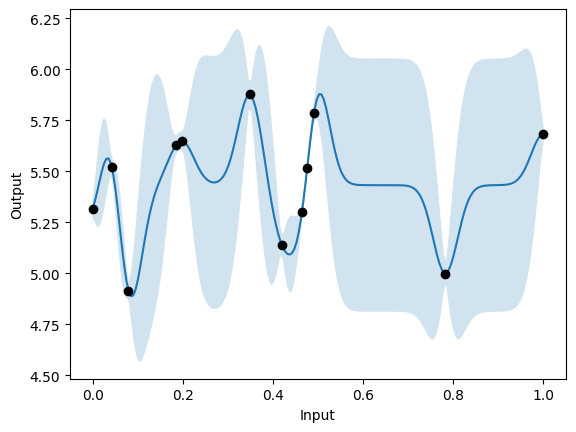

In [10]:
# --- Visualize GP for debugging --- #
X_test = torch.linspace(X_low, X_high, 200).unsqueeze(-1)

model_idx = 0
model = all_models.models[model_idx]

model.eval()
with torch.no_grad():
    posterior = model.posterior(X_test)
    mean = posterior.mean.squeeze()
    std = posterior.variance.squeeze().sqrt()

# Plot
fig, ax = plt.subplots()
ax.plot(X_test.squeeze().numpy(), mean.numpy(), label="GP mean")
ax.fill_between(
    X_test.squeeze().numpy(),
    (mean - 2 * std).numpy(),
    (mean + 2 * std).numpy(),
    alpha = 0.2,
    label = "2std"
)
ax.scatter(X.squeeze().numpy(), Y_aug.squeeze().numpy(), c="black", zorder=3, label="observations")
ax.set_xlabel("Input")
ax.set_ylabel("Output")
plt.show()

# Synthetic data for testing

In [195]:
# --- Synthetic test data --- #
# amp: changes the synthetic data generator for the three conditions
# 1.0: condition 1, 2.0: condition 2, 3.0 condition 3
def compute_difference(in_flow, amp=1.0):
    x = in_flow
    return 1/(1+np.exp(-0.2*amp*(x-5*amp)))+0.5*np.sin(x)-0.02*x+5

def compute_velocity(in_flow, amp=1.0):
    x = in_flow
    return np.sqrt(x)+0.5*amp*np.cos(x)

def compute_ss(in_flow, amp = 1.0):
    x = in_flow
    return (2*x**2)/np.exp(x)+0.3/amp*np.sin(x)+0.3*x

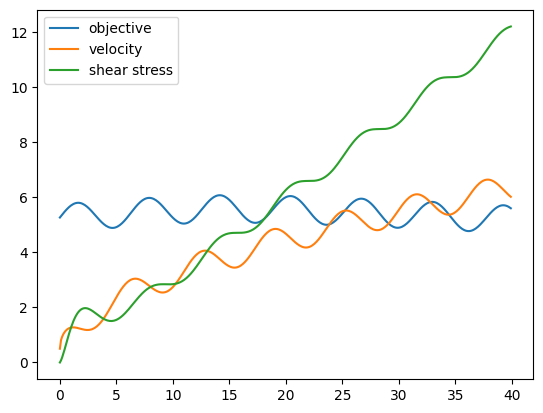

In [196]:
# --- Visualize the functions for flat condition --- #
X = np.arange(0,40,0.1)
plt.plot(X, compute_difference(X), label="objective")
plt.plot(X, compute_velocity(X), label="velocity")
plt.plot(X, compute_ss(X), label="shear stress")
plt.legend()

In [197]:
# --- Make synthetic data --- #
X = np.random.rand(12)*40
data = []
for x in X:
    row = [x]
    for i in range(1,4,1):
        row.append(compute_difference(x, amp=i))
    for i in range(1,4,1):
        row.append(compute_velocity(x, amp=i))
        row.append(compute_ss(x, amp=i))
    data.append(row)
data = np.array(data)

In [198]:
df = pd.DataFrame(data=data, columns=["input","output_flat","output_50","output_15","v_flat","s_flat","v_50","s_50","v_15","s_15"])
df.to_csv("test.csv", index=False)
df

,input,output_flat,output_50,output_15,v_flat,s_flat,v_50,s_50,v_15,s_15
0,18.759834,5.520027,5.550802,5.485161,4.829251,5.601075,5.327240,5.614515,5.825229,5.618995
1,13.870948,6.059945,6.029647,5.541802,3.855915,4.451080,3.987457,4.306364,4.119000,4.258126
2,19.306633,5.780432,5.810932,5.764354,4.842605,5.924391,5.291278,5.858192,5.739951,5.836126
3,3.515046,5.173576,4.816810,4.748299,1.409309,1.680131,0.943772,1.734856,0.478236,1.753098
4,38.883490,5.684324,5.685453,5.685462,6.424099,11.942927,6.612536,11.803987,6.800972,11.757674
5,7.539640,5.949028,5.596778,5.335956,2.900436,2.607630,3.055031,2.464980,3.209626,2.417430
6,30.523623,4.994236,4.999996,5.000178,5.838629,8.923531,6.152439,9.040309,6.466250,9.079235
7,16.587989,5.193187,5.215955,5.004539,3.754270,4.745204,3.435704,4.860818,3.117138,4.899355
8,2.105113,5.747374,5.428985,5.388642,1.196274,1.969515,0.941648,1.840423,0.687022,1.797392
9,8.102240,5.972947,5.641467,5.338320,2.723585,2.761238,2.600727,2.615837,2.477869,2.567369
